# Algoritmo de Clasificación

A continuación empezaremos viendo los algoritmos de clasificación, procederemos a compararlos según las técnicas de **Accuracy** y **F1 score**, para poder seleccionar el mejor en nuestro caso.

## 1. Lectura de datos

---


Importamos los datos con los que vamos a trabajar, para ello utilizaremos la librería *ucimlrepo*, que nos permite descargar directamente el Dataset de **la calidad del vino**.

Para evitar que se nos muestre todo el dataset, haremos una previsualización del conjunto de datos mostrando las primeras líneas mediante el método *head()*. De esta forma podemos entender mejor la estructura sin la necesidad de ver datos masivos pudiendo entender mejor la estructura 

Dividiremos los datos en dos variables:
- X = Donde estarán nuestras variables de entrada, es decir las características del vino. Estas serán utilizadas para realizar las predicciones 
- y = Donde esta nuestra variable objetivo que queremos predecir. En esta ocasión nos centraremos en el **quality**, que representa la calidad del vino 

Hay que tener en cuenta que según si vamos a utilizar:

- Un algoritmo de Clasificación tenemos que hacer una predicción de la calidad del vino como una variable categórica, el dato de **quality** tiene valores que se interpretan como etiquetas de clase que indican los diferentes niveles de calidad del vino.
- En los algoritmos de Regresión tenemos que hacer una predicción de la calidad del vino como una variable continua, utilizando la variable **quality** que representara el nivel de calidad del vino mediante valores numéricos.

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
# Descarga del dataset
wine_quality = fetch_ucirepo(id=186)

# Datos brutos en formato Dataframe de pandas
X = wine_quality.data.features
y = wine_quality.data.targets["quality"]  
  
data = pd.concat([X, y], axis=1)
data.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Para comprobar que ningún dato de nuestra tabla puede ser irrelevante para el modelo, se realizara un análisis de correlación entre las variables.

Para esto se utiliza la matriz de correlación (que nos muestra la relación entre las variables), si una variable tiene una correlación alta con la variable objetivo, es decir, la calidad del vino, entonces esa variable es relevante para el modelo, si una variable tiene una correlación baja con la variable objetivo, entonces esa variable es irrelevante para el modelo y se puede eliminar.

En nuestro caso la lectura que podemos hacer es que todos los datos tienen una alta correlación entre ambas variables, lo que puede ser un indicio de que el dataset es adecuado para la clasificación. 

Sin embargo, es importante tener en cuenta que la correlación no implica causalidad, por lo que realizaremos un análisis adicional para determinar si estas variables realmente influyen en la calidad del vino.


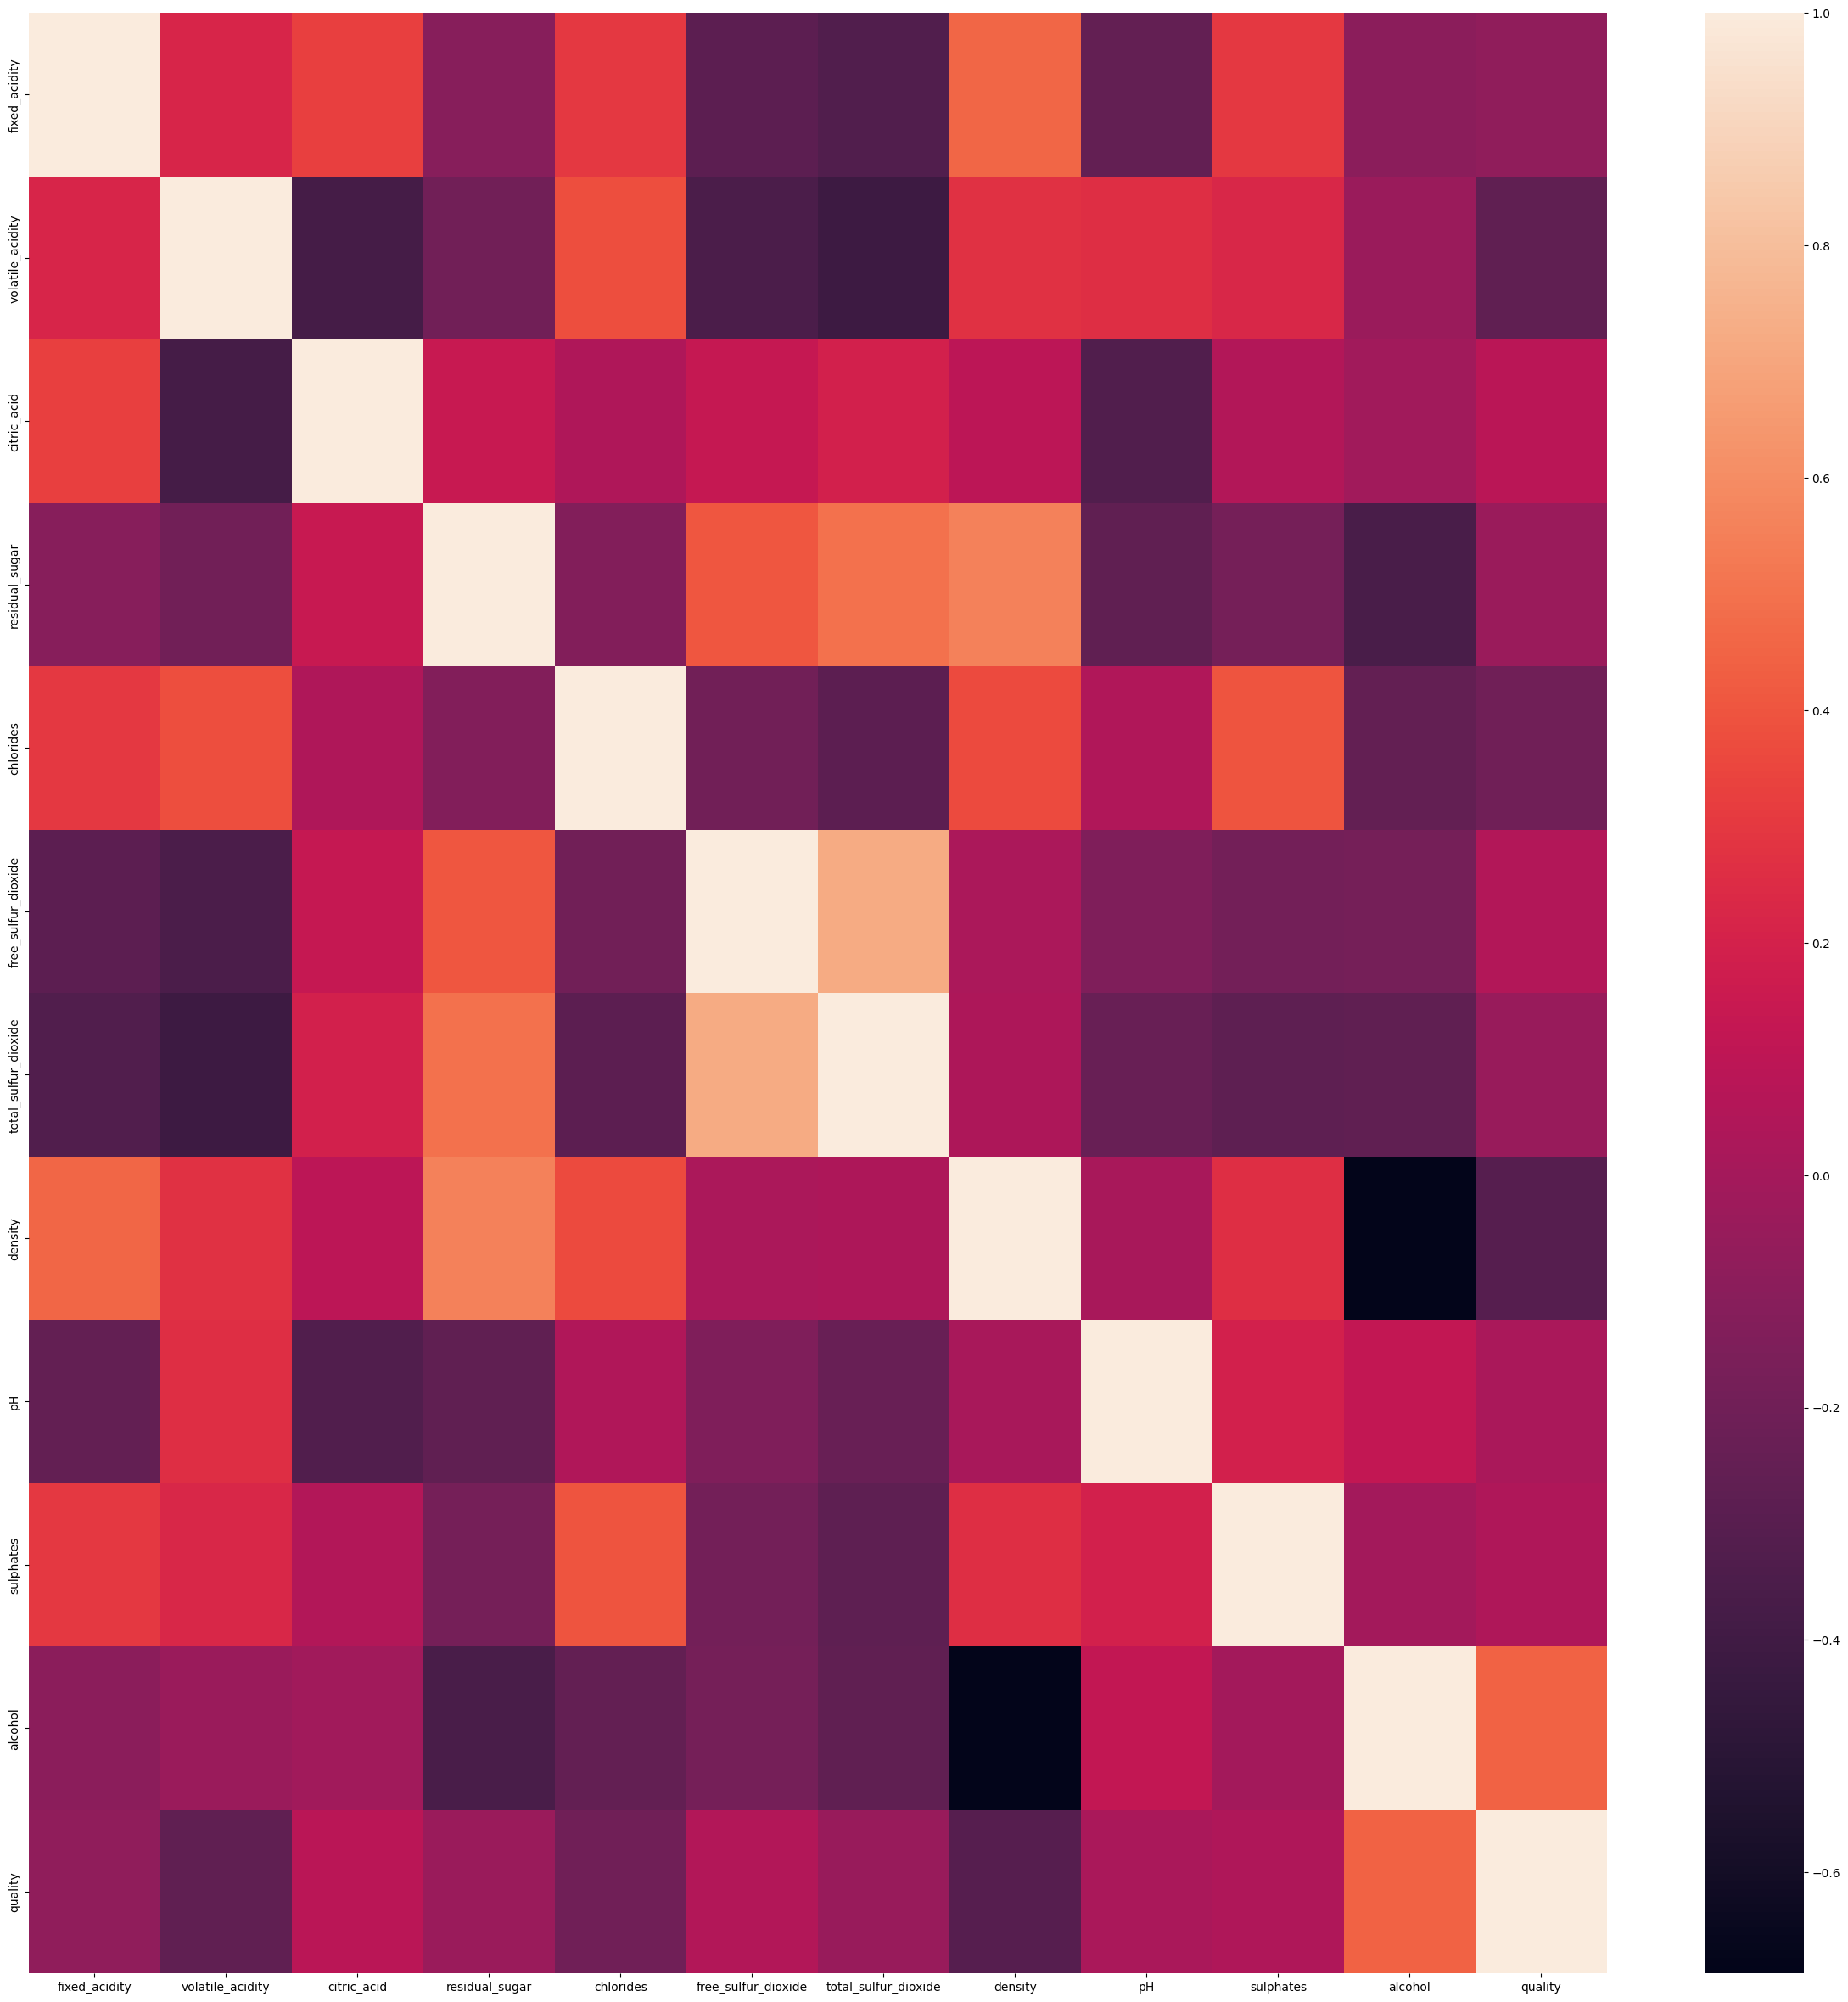

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la matriz de correlación
corrs = data.corr()
plt.figure(figsize=(30,30))
sns.heatmap(corrs)
plt.show()

## 2. Datos de entrenamiento y de prueba

---

A continuación, haremos una división de los conjuntos:
- **Conjunto de entrenamiento:** donde entrenaremos el modelo de aprendizaje automático.
- **Conjunto de prueba:** lo utilizaremos más tarde para poder evaluar el rendimiento

Establecemos el random_state a 42 para que se pueda garantizar que la división de los datos sea reproducible, es decir, que cada vez que se ejecute el código se obtenga la misma partición de los datos.

Según el resultado obtenido podemos interpretar lo siguiente:
- 5197 vinos se utilizan para entrenar el modelo.
- 1300 vinos se utilizan para evaluar el modelo.
- Cada vino está descrito mediante 11 características. 

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape)

(5197, 11) (1300, 11)


## 3. Algoritmo de Clasificacion
---

Ahora procederemos a aplicar los distintos algoritmos de clasificación que conocemos, para comprobar cual es el mejor para nuestro modelo con el objetivo de predecir la calidad del vino a partir de sus características.

Posteriormente al entrenamiento de los modelos con los datos de entrenamiento proporcionados anteriormente, evaluaremos su rendimiento según las técnicas de Accuracy y F1-score, lo que nos permitirá comparar las capacidades de cada algoritmo.

Cuando hemos obtenido todos los datos correspondientes de los modelos haremos una comparación entre ellos para poder comprobar cual es el que presenta mejor desempeño.

Finalmente el modelo seleccionado procederemos a realizar un análisis más detallado de sus resultados mediante una matriz de confusión, para poder observar con una mayor claridad su comportamiento de clasificación.


### 3.1. Modelo de KNN (KNeighborsClassifier)

Empezaremos con el modelo de KNN, pero antes de empezar con el entrenamiento primero tenemos que saber los mejores parámetros para nuestro Dataset.

Para ello definimos los parámetros que se van a evaluar:
- **neighbors_range = range(1, 31)**: los números de vecinos que el algoritmo va tener en cuenta para realizar la predicción, escogemos ese rango porque nos permite evaluar diferentes configuraciones sin incrementar el coste computacional.
- **weights_options = ['uniform', 'distance']**: Como se podrá la influencia de los vecinos.
- **metric_options = ['euclidean', 'manhattan']**: son métricas de distancia para calcular la similitud entre los datos.

Procederemos a hacer un bucle for, para probar todas las combinaciones posibles ente estos parámetros mediante validación cruzada, es decir que evaluamos el rendimiento del modelo utilizando varias peticiones del DataSet. Haremos esto con el objetivo de poder encontrar la configuración que ofrece el mejor rendimiento.

Los resultados que obtenemos son los siguientes:
- Se utilizarán 22 vecinos -> **n_neighbors: 22**
- Los vecinos más cercanos serán lo que mayor peso tengan -> **weights: distance**
- Calcularemos la distancia mediante la métrica de Manhattan -> **metric: manhattan**

El Best cross-validation score (0.5915) nos informa de la media del rendimiento de la modelo obtenida durante la validación cruzada con los mejores parámetros encontrados, es decir que ha habido un 59% de acierto promedio durante la validación.

In [31]:
#Confirmamos cuales son los mejores parametros para KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

neighbors_range = range(1, 31)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan']

best_score = 0
best_params = {}

for weight in weights_options:
  for metric_option in metric_options:

    for neighbors in neighbors_range:

            knn = KNeighborsClassifier(n_neighbors=neighbors, weights=weight, metric=metric_option)
            #cv lo bajamos a 4 en vez de 5 porque mi quality tiene 6 clases, entonces con 5 se me quedaba una clase sin representar en alguna de las particiones, y eso me daba un error
            scores = cross_val_score(knn, X_train, y_train, cv=4)
            mean_score = scores.mean()
            #total_scores.append(mean_score)
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'n_neighbors': neighbors, 'weights': weight, 'metric': metric_option}

print("Best parameters:", best_params)
print("Best cross-validation score:", f"{best_score:.4f}")

Best parameters: {'n_neighbors': 22, 'weights': 'distance', 'metric': 'manhattan'}
Best cross-validation score: 0.5915


Ahora según los datos que hemos obtenido en el proceso anterior, vamos a crear el modelo KNN. Para ello extraemos los valores de best_params, para que se inicialice el clasificador con esos parámetros.

Entrenaremos el modelo con el conjunto de datos del entrenamiento (X_train, y_train), con el objetivo de que el algoritmo aprenda la relación entre las características del vino y su nivel de calidad.


In [32]:
#parameters
n_neighbors = best_params["n_neighbors"]
weights = best_params["weights"]
metric = best_params["metric"]
# constructor
KNN = KNeighborsClassifier(n_neighbors= n_neighbors, weights=weights, metric = metric)
# fit and predict
KNN.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",22
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 3.2. Modelo SVM (SVC)

Ahora continuaremos entrenando el modelo SVC, que es una implementación del algoritmo para problemas de clasificación. 

Durante las pruebas se observó que al hacer el entrenamiento utilizando el kerner lineal presentaba un tiempo de ejecución elevado, llegando a tardar minutos debido al tamaño del conjunto de los datos y la complejidad del algoritmo.

Para este modelo además de establecer el kerner como lineal, también hemos tenido en cuenta los siguientes parámetros:
- **C = 1**, para poder controlar el equilibrio entre la minimización de los errores y mantener un margen amplio entre las clases.
- **random_state = 42**, para la reproducibilidad de los datos.

Una vez configurado el modelo, se procede a entrenarlo utilizando el conjunto de datos de entrenamiento (X_train, y_train), con el objetivo de que el algoritmo aprenda la relación entre las características del vino y su nivel de calidad.

In [38]:
from sklearn.svm import SVC
# Usar train para evitar sobreajuste y reducir tiempo de cómputo
#Continue usando SVC, pero al hacer el entrenamiento de todos los datos tarda mucho
SVN = SVC(kernel='linear', C=1, random_state=42)
SVN.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 3.3. Modelo de Naive Bayes (GaussianNB)

El modelo Naive Bayes la implementaremos con el sklearn mediante la clase GaussianNB, el cual se basa en el teorema de Bayes y asumen que las variables son independientes entre sí.

Utilizaremos una configuración por defectos, porque GaussianNB dispone de pocos hiperparámetros y suele tener un bien rendimiento sin la necesidad de realizar ningún ajuste adicional.

Posteriormente, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train), permitiendo que el algoritmo aprenda la relación entre las características del vino y su nivel de calidad.

In [33]:
from sklearn.naive_bayes import GaussianNB
NaiveBayes = GaussianNB()
NaiveBayes.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### 3.4. Tree (DecisionTreeClassifier)

Para entrena el modelo de Tree nos centraremos en la clase de DecisionTreeClassifier, que funciona dividiendo el conjunto de datos en diferentes ramas según las características que mejor separan las clases.

El modelo construye una estructura en árbol donde cada nodo representa una condición sobre una característica del dataset, permitiendo clasificar los datos de forma progresiva hasta llegar a una predicción final.

En este caso se utiliza la configuración predeterminada.

Posteriormente, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train), con el objetivo de que el algoritmo aprenda las reglas necesarias para clasificar la calidad del vino a partir de sus características.

In [34]:
from sklearn.tree import DecisionTreeClassifier
Tree = DecisionTreeClassifier()
Tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### 3.5. Forest (RandomForestClassifier)


El modelo Forest estará enfocado al sklearn de la clase RandomForestClassifier, que se basa en la combinación de múltiples árboles de decisión para mejorar la capacidad de predicción del modelo.

Random Forest genera varios árboles de decisión de forma independiente y combina posteriormente los resultados, consiguiendo que la predicción final se obtenga a partir de la votación de todos los árboles, lo que permite reducir el sobreajuste y mejorar la estabilidad del modelo.

Aqui haremos una pequeña configuración:
- **(n_estimators = 1000)**, lo que permite obtener predicciones más robustas al combinar un mayor número de modelos. Este elemento es tan elevado para una mayor estabilidad y reducir la variabilidad de las predicciones.
- **random_state = 0**, para garantizar la reproducibilidad de los resultados.

Posteriormente, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train), permitiendo que el algoritmo aprenda patrones más complejos a partir de las características del vino.

In [35]:
from sklearn.ensemble import RandomForestClassifier

Forest = RandomForestClassifier(n_estimators=1000, random_state=0)
Forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

### 3.6. Extra (LinearSVC)

Al ver que el entrenamiento del modelo SVC tenía un tiempo tan largo de procesamiento, por ello buscamos una alternativa. Por eso utilizamos el modelo *LLinearSVC* se utiliza en problemas lineales y está centrado en trabajar con conjuntos de datos de mayor tamaño, ofreciendo una mejor eficiencia computacional que SVC cuando se utiliza un kernel lineal.

Este modelo lo vamos a utiliza como adicional, ya que ofrece tiempos de entrenamiento mucho más rápidos que SVC cuando se trabaja con grandes conjuntos de datos. Se utiliza una configuración predeterminada.

Posteriormente, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train) para que el algoritmo aprenda la relación entre las características del vino y su nivel de calidad.

In [36]:
#para una gran cantidad de datos, es similar a SVC pero con una mejor eficiencia computacional
from sklearn.svm import LinearSVC
Linear_SVC = LinearSVC()
Linear_SVC.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

## 4. Tecnicas de evaluación de Clasificación
---

Una vez entrenado todos los modelos, ahora procederemos a hacer una evaluación, para ello utilizaremos **Accuracy** y **F1 score**, para ello haremos lo siguiente:
- Establecemos un array **results=[]**, donde se quedarán almacenados los resultados que nos proporciona las técnicas.
- Establecemos un diccionario que contenga todos los modelos de clasificación que hemos entrenado anteriormente, con sus nombres claves. Permitiéndonos iterar sobre cada modelo para evaluar posteriormente su rendimiento.
- Un bucle donde se realizan todas las técnicas de evaluación según el modelo de clasificación que tenga e imprime sus resultados
    - En este bucle para las técnica de evaluación de F1 score tenemos que añadir el parámetro de *average='macro'*, porque el dataset tiene varias clases y queremos obtener un promedio de las métricas para cada clase, de forma predeterminada seria binary, pero mi dataset no solo tiene 1 o 0.
    - Accuaracy lo dejamos con los parámetros predeterminados.
- Los resultados según se vayan obteniendo se van guardando en el array resultado con el nombre del modelo y su parámetro de la técnica.


In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

results = []

#from sklearn import metrics
models= {
    "KNN": KNN,
    "SVM": SVN,
    "NaiveBayes": NaiveBayes,
    "DecisionTree": Tree,
    "RandomForest": Forest,
    "LinearSVC": Linear_SVC
}

#Hace todas las metricas segun los modelos de clasificacion que tengo e imprime los resultados
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Resultados para {name}:")

    #metricas de evaluacion
    accuracy = accuracy_score(y_test, y_pred)
    #Aqui utilizamos el average macro, porque el dataset tiene varias clases y queremos obtener un promedio de las métricas para cada clase,
    #de forma predeterminada seria binary, pero mi dataset no solo tiene 1 o 0
    f1 = f1_score(y_test, y_pred, average='macro')
    
    #lo utilizaremos posteriormente para crear una tabla para que se vea mejor la comparacion 
    results.append({
        "Modelo": name,
        "Accuracy": accuracy,
        "F1_macro": f1
    })
    
    #4F es para los decimales
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 30)

Resultados para KNN:
Accuracy: 0.6238
F1 Score: 0.3610
------------------------------
Resultados para SVM:
Accuracy: 0.5254
F1 Score: 0.1689
------------------------------
Resultados para NaiveBayes:
Accuracy: 0.4692
F1 Score: 0.2535
------------------------------
Resultados para DecisionTree:
Accuracy: 0.5931
F1 Score: 0.3512
------------------------------
Resultados para RandomForest:
Accuracy: 0.6808
F1 Score: 0.3909
------------------------------
Resultados para LinearSVC:
Accuracy: 0.5169
F1 Score: 0.1679
------------------------------


Con los datos que hemos obtenido los ordenamos en una tabla para una mejor visualización, primero escogemos que se ordene de mayor a menor, cogiendo como columna principal *F1 macro*.

In [40]:
df_results_classification = pd.DataFrame(results)
df_results_classification = df_results_classification.sort_values(by="F1_macro", ascending=False).reset_index(drop=True)
print("\nComparación de modelos:")
print(df_results_classification)


Comparación de modelos:
         Modelo  Accuracy  F1_macro
0  RandomForest  0.680769  0.390901
1           KNN  0.623846  0.360950
2  DecisionTree  0.593077  0.351249
3    NaiveBayes  0.469231  0.253488
4           SVM  0.525385  0.168933
5     LinearSVC  0.516923  0.167945


Luego nos proporcionara el mejor modelo según la columna destacada, en este caso, según *F1*, el mejor es **RandomForest**.

In [41]:
best_model_name = df_results_classification.iloc[0]["Modelo"]
best_model = models[best_model_name]
print(f"\nMejor modelo: {best_model_name}")


Mejor modelo: RandomForest


Posteriormente hacemos el mismo proceso anterior, pero esta vez teniendo en cuenta *Accuracy*, según esta técnica de evaluación coincide con *F1* y el mejor modelos es **RandomForest**.

In [42]:
df_results_classification_classification = pd.DataFrame(results)
df_results_classification = df_results_classification.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
print("\nComparación de modelos:")
print(df_results_classification)


Comparación de modelos:
         Modelo  Accuracy  F1_macro
0  RandomForest  0.680769  0.390901
1           KNN  0.623846  0.360950
2  DecisionTree  0.593077  0.351249
3           SVM  0.525385  0.168933
4     LinearSVC  0.516923  0.167945
5    NaiveBayes  0.469231  0.253488


In [43]:
best_model_name = df_results_classification.iloc[0]["Modelo"]
best_model = models[best_model_name]
print(f"\nMejor modelo: {best_model_name}")


Mejor modelo: RandomForest


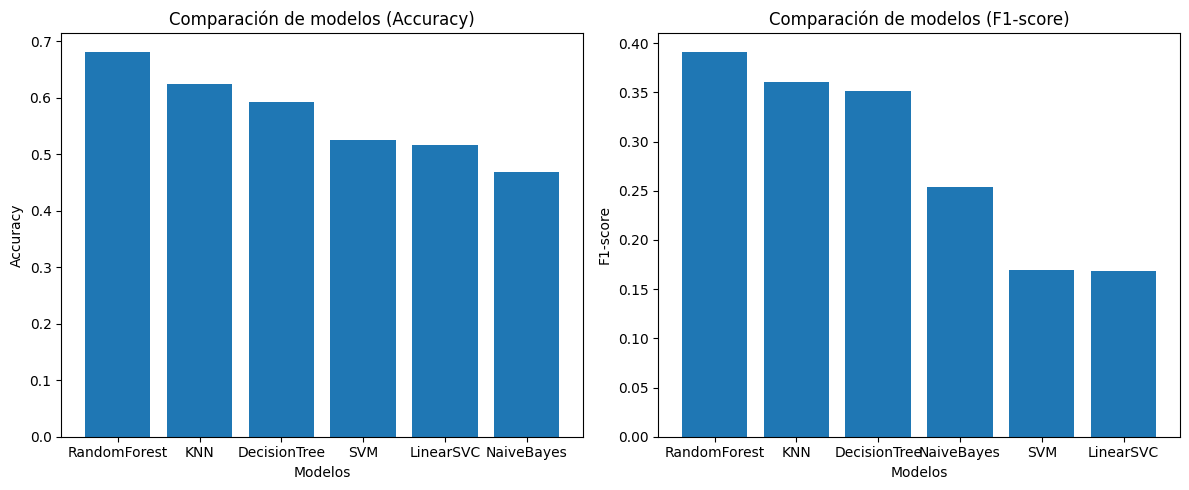

In [71]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Accuracy (mayor es mejor)
df_acc = df_results_classification.sort_values(by="Accuracy", ascending=False)
axes[0].bar(df_acc["Modelo"], df_acc["Accuracy"])
axes[0].set_title("Comparación de modelos (Accuracy)")
axes[0].set_ylabel("Accuracy")
axes[0].set_xlabel("Modelos")

# F1 Score (mayor es mejor)
df_f1 = df_results_classification.sort_values(by="F1_macro", ascending=False)
axes[1].bar(df_f1["Modelo"], df_f1["F1_macro"])
axes[1].set_title("Comparación de modelos (F1-score)")
axes[1].set_ylabel("F1-score")
axes[1].set_xlabel("Modelos")

plt.tight_layout()
plt.show()

## 5. Visualizacion del modelo escogido de Clasificación

### 5.1. Confusion Matrix Display 

El modelo que vamos a selecciona en nuestros casos según nuestros resultados va a ser **RandomForest**, procederemos a analizar sus resultados mediante una matriz de confusión, lo que nos permite visualizar el número de predicciones correctas e incorrectas realizadas por el modelo para cada una de las clases.

En la matriz de confusión, las filas representan las clases reales y las columnas las clases predichas por el modelo. Los valores situados en la diagonal principal corresponden a las predicciones correctas, mientras que los valores fuera de la diagonal representan errores de clasificación.

Los datos que me muestra mi matriz son que los valores más altos se encuentran en la diagonal y son:
- quality 5 → 295
- **quality 6 → 453**
- quality 7 → 120 

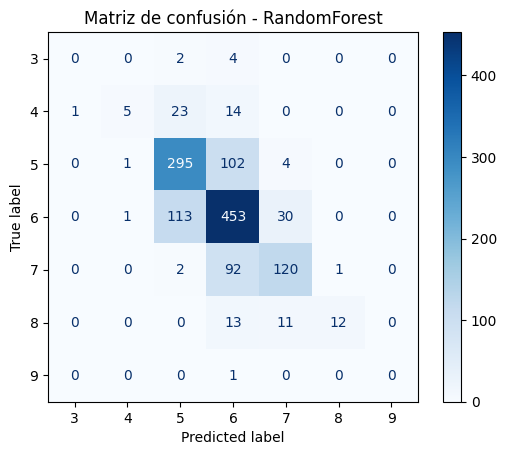

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Predicción del mejor modelo
y_pred_best = best_model.predict(X_test)

# Matriz de confusión del mejor modelo
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Matriz de confusión - {best_model_name}")
plt.show()

## 6. Algoritmos de Regresión

A continuación, se aplicarán los distintos algoritmos de regresión con el objetivo de predecir la calidad del vino a partir de sus características.

Una vez entrenados los modelos utilizando los datos de entrenamiento obtenidos anteriormente, se evaluará su rendimiento mediante métricas propias de regresión como Mean Absolute Error (MAE), Mean Squared Error (MSE) y R². Estas métricas permitirán analizar el error de las predicciones y comparar el comportamiento de los diferentes algoritmos.

Una vez obtenidos los resultados correspondientes a cada modelo, se realizará una comparación entre ellos con el fin de identificar cuál ofrece un mejor rendimiento en la predicción de la calidad del vino.

Finalmente, se seleccionará el modelo con mejores resultados y se analizarán sus métricas para interpretar con mayor detalle su capacidad predictiva.

### 6.1. Modelo de KNN (KNeighborsRegressor)

Para este modelo planteamos la misma estructura que la de clasificación, la única diferencia es que estaremos utilizando *KNeighborsRegressor* y los datos que vemos son diferentes.

- Se utilizarán 16 vecinos -> **n_neighbors: 16**.
- Los vecinos más cercanos serán lo que mayor peso tengan -> **weights: distance**.
- Calcularemos la distancia mediante la métrica de Manhattan -> **metric: manhattan**.

El único dato que varía es los vecinos que va a utilizar.

El Best cross-validation score (0.3744) nos informa de la media del rendimiento de la modelo obtenida durante la validación cruzada con los mejores parámetros encontrados, es decir que ha habido un 37% de acierto promedio durante la validación.

Esto es tan poco debido a que la relación entre las características del vino y su calidad no es completamente lineal y puede depender de otros factores no presentes en el dataset.

In [46]:
#Confirmamos cuales son los mejores parametros para KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

neighbors_range = range(1, 31)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan']

best_score = float('-inf')  # Initialize with negative infinity since we want to maximize the score
best_params = {}


for weight in weights_options:
  for metric_option in metric_options:
    for neighbors in neighbors_range:
      knn_regressor = KNeighborsRegressor(n_neighbors=neighbors, weights=weight, metric=metric_option)
    
      scores = cross_val_score(knn_regressor, X_train, y_train, cv=4)

      mean_score = scores.mean()
      if mean_score > best_score:
          best_score = mean_score
          best_params = {'n_neighbors': neighbors, 'weights': weight, 'metric': metric_option}

print("Best parameters:", best_params)
print("Best cross-validation score:", f"{best_score:.4f}")


Best parameters: {'n_neighbors': 16, 'weights': 'distance', 'metric': 'manhattan'}
Best cross-validation score: 0.3744


Ahora según los datos que hemos obtenido en el proceso anterior, vamos a crear el modelo KNN. Para ello extraemos los valores de best_params, para que se inicialice el regresor con esos parámetros

Entrenaremos el modelo con el conjunto de datos del entrenamiento (X_train, y_train), con el objetivo de que el algoritmo aprenda la relación entre las características del vino y su nivel de calidad.

In [47]:
#parameters
n_neighbors = best_params["n_neighbors"]
weights = best_params["weights"]
metric = best_params["metric"]
# constructor
knnR = KNeighborsRegressor(n_neighbors= n_neighbors, weights=weights, metric = metric)
# fit and predict
knnR.fit(X = X_train, y = y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",16
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 6.2. Modelo SVM (SVR)

Entrenaremos el modelo SVR (Support Vector Regressor), que es una implementación del algoritmo Support Vector Machines (SVM) adaptada para problemas de regresión.

Este modelo busca encontrar una función que permita aproximar lo mejor posible la relación entre las características del vino y su nivel de calidad, minimizando el error de predicción dentro de un margen determinado.

En este caso se utilizan los parámetros por defecto del modelo, lo que permite obtener una primera aproximación del rendimiento del algoritmo sin realizar ajustes adicionales de hiperparámetros.

Posteriormente, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train), permitiendo que el algoritmo aprenda la relación entre las características del vino y el valor numérico de su calidad.

Con respecto al tiempo de entrenamiento, a diferencia del de clasificación el de regresión es mucho menor y se debe a que el algoritmo debe estimar un valor continuo. 

In [48]:
from sklearn.svm import SVR
SVR= SVR()
SVR.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


### 6.3. Modelo Linear Model

Para el modelo Linear Regression, utilizamos la clase LinearRegression, es uno de los algoritmos más simples y se utiliza en problemas de regresión, ya que busca establecer una relación lineal entre las variables independientes y la variable objetivo.

Se utilizarán los parámetros por defecto, ya que LinearRegression no requiere un ajuste complejo de hiperparámetros para obtener una primera estimación del comportamiento del algoritmo.

Finalmente, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train), permitiendo que el algoritmo aprenda la relación entre las características del vino y el valor numérico de su calidad.

In [49]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 6.4. Modelo Tree (DecisionTreeRegressor)

El modelo Tree, implementado en sklearn mediante la clase DecisionTreeRegressor, funciona dividiendo el conjunto de datos en diferentes ramas según las características que mejor permiten predecir el valor objetivo.

En un problema de regresión, el árbol va creando divisiones en los datos hasta llegar a nodos finales o hojas, donde se calcula una estimación del valor de la variable objetivo.

Para este modelo se han configurado algunos parámetros para poder controlar la complejidad del árbol y evitar el sobreajuste:

- **criterion = 'friedman_mse':** se utiliza para medir la calidad de las divisiones del árbol basándose en el error cuadrático.
- **max_depth = 12:** limita la profundidad máxima del árbol para evitar que el modelo se vuelva demasiado complejo.
- **min_samples_split = 5:** establece el número mínimo de muestras necesarias para dividir un nodo.
- **min_samples_leaf = 2:** asegura que cada hoja tenga al menos dos muestras.
- **random_state = 0:** permite garantizar la reproducibilidad de los resultados.

Una vez definidos los parámetros, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train) para que el algoritmo aprenda las relaciones entre las características del vino y el valor numérico de su calidad.

In [50]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(
    criterion='friedman_mse', 
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2, 
    random_state=0)

tree_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'friedman_mse'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_

### 6.5. Modelo Forest (RandomForestRegressor)


El modelo Forest, usa el sklearn mediante la clase RandomForestRegressor y se basa en la combinación de múltiples árboles de decisión para mejorar la capacidad de predicción del modelo.

El funcionamiento de Random Forest consiste en generar varios árboles de decisión de forma independiente utilizando diferentes subconjuntos de los datos. Posteriormente, las predicciones de todos los árboles se combinan para obtener una estimación final más robusta.

En este caso se han configurado algunos parámetros para controlar el comportamiento del modelo:

- **n_estimators = 1000:** número de árboles de decisión que formarán el bosque.
- **max_depth = 2:** limita la profundidad de cada árbol para evitar que el modelo se vuelva demasiado complejo.
- **criterion = 'friedman_mse':**criterio utilizado para evaluar la calidad de las divisiones del árbol.
- **random_state = 0:** garantiza la reproducibilidad de los resultados.

Finalmente, el modelo se entrena utilizando el conjunto de datos de entrenamiento (X_train, y_train), permitiendo que el algoritmo aprenda las relaciones entre las características del vino y el valor numérico de su calidad.

In [51]:
from sklearn.ensemble import RandomForestRegressor

#1.1 Model Parametrization
ForestR = RandomForestRegressor(
    n_estimators= 1000, 
    max_depth = 2, 
    criterion='friedman_mse', 
    random_state=0)
#1.2 Model construction
ForestR.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'friedman_mse'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

## 7. Metricas de evaluación de Regresión

---

Una vez entrenado todos los modelos, ahora procederemos a hacer una evaluación, para ello utilizaremos **MAE**, **MSE** y **R²**, para ello haremos lo siguiente:

- Establecemos un array **results=[]**, donde se quedarán almacenados los resultados que nos proporciona las métricas.
- Establecemos un diccionario que contenga todos los modelos de regresión que hemos entrenado anteriormente, con sus nombres claves. Permitiéndonos iterar fácilmente sobre cada modelo para evaluar posteriormente su rendimiento.
- Un bucle donde se realizan todas las métricas de evaluación según el modelo de regresión que tenga e imprima sus resultados.
- Los resultados según se vayan obteniendo se van guardando en el array resultado con el nombre del modelo y su parámetro de la técnica.


In [52]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

results = []

#from sklearn import metrics
models= {
    "SVR": SVR,
    "KNNR": knnR,
    "Linear Regression": lin_reg,
    "Decision Tree": tree_reg,
    "Random Forest": ForestR
}
#Hace todas las metricas segun los modelos de clasificacion que tengo e imprime los resultados

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Resultados para {name}:")

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    #lo utilizaremos posteriormente parafcrear una tabla para que se vea mejor la comparacion 
    results.append({
        "Modelo": name,
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    })
    
    #4F es para los decimales
    #print(f"Accuracy: {accuracy:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2: {r2:.4f}")
    print("-" * 30)

Resultados para SVR:
MAE: 0.6149
MSE: 0.6336
R2: 0.1421
------------------------------
Resultados para KNNR:
MAE: 0.4479
MSE: 0.4539
R2: 0.3855
------------------------------
Resultados para Linear Regression:
MAE: 0.5659
MSE: 0.5467
R2: 0.2598
------------------------------
Resultados para Decision Tree:
MAE: 0.5769
MSE: 0.6579
R2: 0.1092
------------------------------
Resultados para Random Forest:
MAE: 0.5987
MSE: 0.5761
R2: 0.2200
------------------------------


Con los datos que hemos obtenido los ordenamos en una tabla para una mejor visualización.

In [53]:
df_results = pd.DataFrame(results)

print("\nComparación de modelos de regresión:")
print(df_results)


Comparación de modelos de regresión:
              Modelo       MAE       MSE        R2
0                SVR  0.614902  0.633603  0.142095
1               KNNR  0.447950  0.453873  0.385451
2  Linear Regression  0.565871  0.546696  0.259767
3      Decision Tree  0.576855  0.657912  0.109180
4      Random Forest  0.598666  0.576092  0.219966


Luego nos proporcionara el mejor modelo según la columna destacada, hay que tener en cuenta que cuanto menor sea el MAE o el MSE, mejor es el modelo, por eso lo ordenamos de forma ascendente.

Según la métrica de MAE y MSE, nos informa que el mejor modelo es KNeighborsRegressor.

In [54]:
df_results = df_results.sort_values(by="MAE")
#cuanto menor sea el MAE, mejor es el modelo, por eso lo ordenamos de forma ascendente

print(df_results)

print("\nMejor modelo:", df_results.iloc[0]["Modelo"])

              Modelo       MAE       MSE        R2
1               KNNR  0.447950  0.453873  0.385451
2  Linear Regression  0.565871  0.546696  0.259767
3      Decision Tree  0.576855  0.657912  0.109180
4      Random Forest  0.598666  0.576092  0.219966
0                SVR  0.614902  0.633603  0.142095

Mejor modelo: KNNR


In [55]:
df_results = df_results.sort_values(by="MSE")
#cuanto menor sea el MAE, mejor es el modelo, por eso lo ordenamos de forma ascendente
print(df_results)

print("\nMejor modelo:", df_results.iloc[0]["Modelo"])

              Modelo       MAE       MSE        R2
1               KNNR  0.447950  0.453873  0.385451
2  Linear Regression  0.565871  0.546696  0.259767
4      Random Forest  0.598666  0.576092  0.219966
0                SVR  0.614902  0.633603  0.142095
3      Decision Tree  0.576855  0.657912  0.109180

Mejor modelo: KNNR


Luego nos proporcionara el mejor modelo segun la columna destacada, hay que tener en cuenta que cuanto que en esta ocasion es en orden ascendente porque R2 es mejor cuanto más alto sea

Segun la metrica de R², nos informa que el mejor modelo es KNeighborsRegressor

In [56]:
df_results = df_results.sort_values(by="R2", ascending=False)
#Es en orden ascendente porque R2 es mejor cuanto más alto sea
print(df_results)
print("\nMejor modelo:", df_results.iloc[0]["Modelo"])



              Modelo       MAE       MSE        R2
1               KNNR  0.447950  0.453873  0.385451
2  Linear Regression  0.565871  0.546696  0.259767
4      Random Forest  0.598666  0.576092  0.219966
0                SVR  0.614902  0.633603  0.142095
3      Decision Tree  0.576855  0.657912  0.109180

Mejor modelo: KNNR


En las siguientes graficas tenemos que tener en cuenta que para el MAE Y MSE, tenemos que coger el valor más bajo y para R2 los valores más altos.

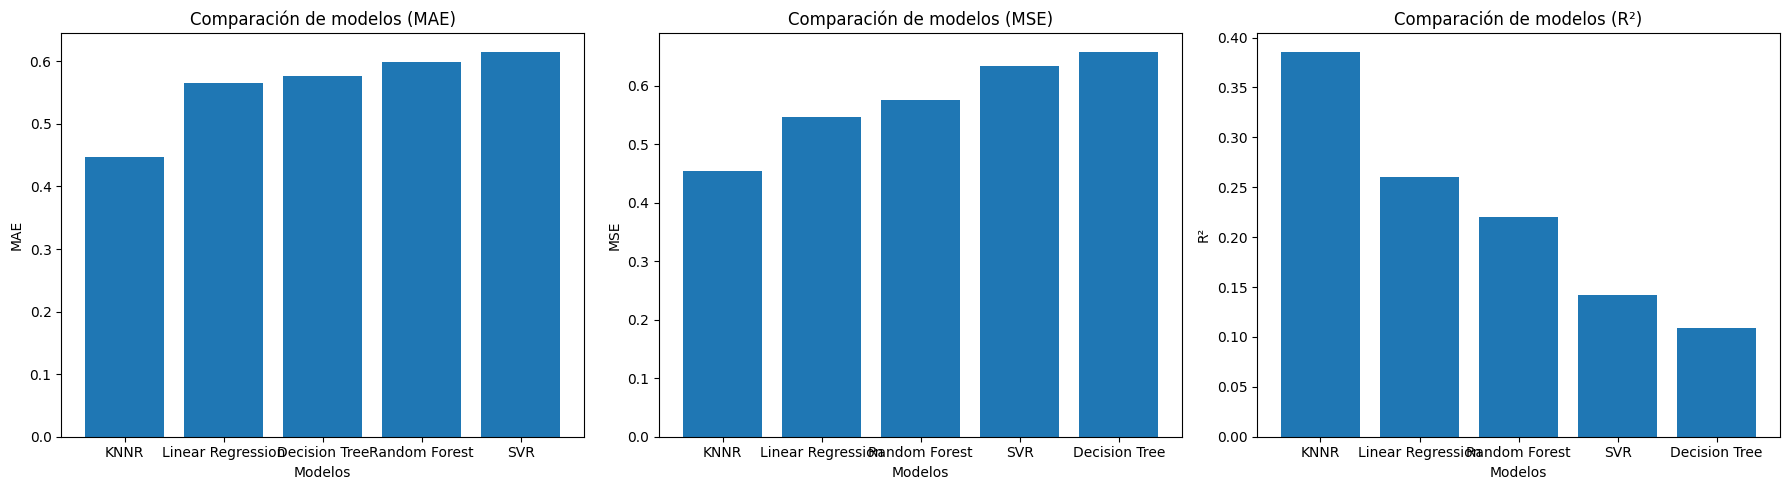

In [66]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# MAE (menor es mejor)
df_mae = df_results.sort_values(by="MAE", ascending=True)
axes[0].bar(df_mae["Modelo"], df_mae["MAE"])
axes[0].set_title("Comparación de modelos (MAE)")
axes[0].set_ylabel("MAE")
axes[0].set_xlabel("Modelos")

# MSE (menor es mejor)
df_mse = df_results.sort_values(by="MSE", ascending=True)
axes[1].bar(df_mse["Modelo"], df_mse["MSE"])
axes[1].set_title("Comparación de modelos (MSE)")
axes[1].set_ylabel("MSE")
axes[1].set_xlabel("Modelos")

# R² (mayor es mejor)
df_r2 = df_results.sort_values(by="R2", ascending=False)
axes[2].bar(df_r2["Modelo"], df_r2["R2"])
axes[2].set_title("Comparación de modelos (R²)")
axes[2].set_ylabel("R²")
axes[2].set_xlabel("Modelos")

plt.tight_layout()
plt.show()

## 8. Grafica del modelo Seleccionado

Para poder ver un poco más utilizamos un gráfico valores reales vs predichos
Este gráfico muestra qué tan bien el modelo predice la calidad del vino.
- Eje X: calidad real del vino (y_test)
- Eje Y: calidad predicha por el modelo (y_pred)
- Línea roja: predicción perfecta (cuando predicho = real)

Podemos interpretar que si los puntos están más cerca de la línea roja, mejor funciona el modelo, aunque los datos se concentren alrededor, hay una dispersión lo que puede significar que el modelo comete errores en algunas predicciones.

También podemos observar que hay una concentración entre 5 y 7, las cuales son las calidades más frecuentes y tiene cierta dificultad en los valores 3 o 9

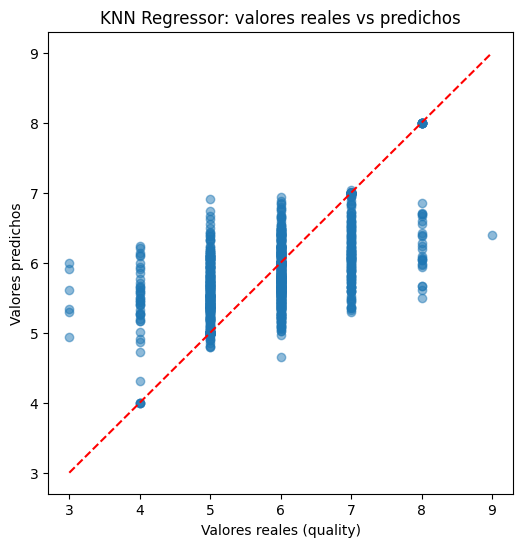

In [65]:
import matplotlib.pyplot as plt

# Predicciones del mejor modelo
y_pred_knn = knnR.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_knn, alpha=0.5)

plt.xlabel("Valores reales (quality)")
plt.ylabel("Valores predichos")
plt.title("KNN Regressor: valores reales vs predichos")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # línea ideal

plt.show()

## 9. Clasificacion vs Regresion 

Vamos a visualizar los datos de evaluación de los metodos que hemos seleccionado

In [151]:
# Filtrar solo los datos de RandomForest
forest_results = df_results_classification[df_results_classification["Modelo"] == "RandomForest"]
print("\nDatos de RandomForest:")
print(forest_results)

print("-" * 40)

# Filtrar solo los datos de KNNR
knn_results = df_results[df_results["Modelo"] == "KNNR"]
print("\nDatos de KNNR:")
print(knn_results)



Datos de RandomForest:
         Modelo  Accuracy  F1_macro
0  RandomForest  0.680769  0.390901
----------------------------------------

Datos de KNNR:
  Modelo      MAE       MSE        R2
1   KNNR  0.44795  0.453873  0.385451


Según los daTos que vemos podemos entender lo siguiente:
- El modelo de clasificación obtiene una accuracy del 68%, lo que significa que predice correctamente la categoría de calidad en la mayoría de los casos y el F1 muestra un equilibrio en la precisión del modelo, mostrando que el clasificador es capaz de identificar razonablemente bien las distintas clases de calidad.
- El modelo de regresión obtiene un R² de 0.38, lo que indica que solo explica alrededor del 38% de la variabilidad de la calidad del vino.

Esto se debe a que la variable **quality** es de tipo categórica, por lo que es una escala discreta, debido a eso los modelos de regresión como lo toman como un valor continuo no clasifica bien los datos y dificulta una representación precisa de los distintos niveles de calidad.

Para una mejor interpretacion lo vamos a hacer graficamente tomando la clasificacion de Accuracy, F1-score y R², no hacemos con MAE y MSE, porque estos no tienen la misma medicion, porque coje los valores negativos

En la grafica podemos ver el rendimiento de los dos modelos deleccionados según su evaluación, estos resultados permiten comparar el comportamiento de ambos enfoques y analizar cuál se adapta mejor.

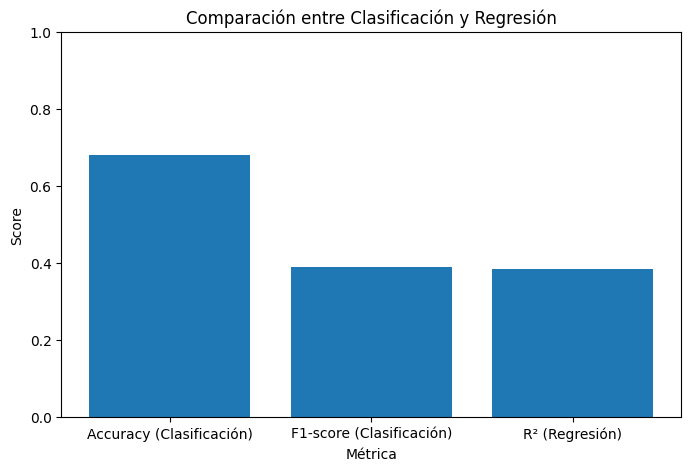

In [70]:
import matplotlib.pyplot as plt

# métricas principales
metrics = ["Accuracy (Clasificación)", "F1-score (Clasificación)", "R² (Regresión)"]
values = [0.680769, 0.390901, 0.385451]

plt.figure(figsize=(8,5))

plt.bar(metrics, values)

plt.title("Comparación entre Clasificación y Regresión")
plt.ylabel("Score")
plt.xlabel("Métrica")

plt.ylim(0,1)

plt.show()

## 10. Conclusión

Como conclusión, tras comparar dos algoritmos diferentes *(clasificación y regresión)* para predecir la calidad del vino, he llegado a la conclusión de que para estos datos es mejor la **Clasificación**, más concretamente el modelo de **Random Forest**.

Esto se debe a que los niveles de *Accuracy* y *F1-score* obtenidos son superiores a los del mejor modelo de regresión (KNN Regressor). La razón principal es que la variable *quality* es categórica y discreta, por lo que la clasificación se adapta mejor a su naturaleza, consiguiendo una predicción más precisa y coherente con los datos.

Debido a que si se toma como continua y numerica puede encontrarse con muchos errores artificiales al intentar predecir valores intermedios.